In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
enrollPerTown = pd.read_csv('neighborhood_enrollment.csv')
#imports enrollment data into enrolPerTown
popPerZip = pd.read_excel('Pennsylvania_DemographicsByZipCode_sample.xlsx',sheet_name='2024AmericanCommunitySurvey', header=4)
#imports population and zip code data into popPerZip

#IMPORTANT - In order to run this code you MUST install

The goal of sorting through this dataset is to find the current enrollment in schools per capita. Their is two main datasets that are needed in order to achive this, that being the enrolment data of each town. As well as the population by town and zip code.

In [2]:
pureEnroll = (enrollPerTown.groupby('neighborhood')['total_students_enrolled'].sum().reset_index())
pureEnroll = pureEnroll[pureEnroll['total_students_enrolled'] > 0]

The code above is just there to combine the enrollment data across grades into just one row per town.

But the next main problem we have is that there is no way to connect the two datasets without converting the towns to zipcodes and then back. I feel that the best way to do this is just to add a matrix in the connects the towns to the zipcodes.

In [3]:
neighToZip = {
    'Bairdford' : '15006',
    'Bakerstown' : '15007',
    'Brackenridge' : '15014',
    'Bradfordwoods' : '15015',
    'Bridgeville' : '15017',
    'Buena Vista' : '15018',
    'Bunola' : '15020',
    'Cheswick' : '15024',
    'Floreffe' : '15025',
    'Jefferson Hills' : '15025',
    'Large' : '15025',
    'Clairton' : '15025',
    'Coulters' : '15028',
    'Creighton' : '15030',
    'Cuddy' : '15031',
    'Curtisville' : '15032',
    'Dravosburg' : '15034',
    'East Mc Keesport' : '15035',
    'Elizabeth' : '15037',
    'Gibsonia' : '15044',
    'Glassport' : '15045',
    'Glenwillard' : '15046',
    'Crescent' : '15046',
    'Greenock' : '15047',
    'Harwick' : '15049',
    'Indianola' : '15051',
    'Leetsdale' : '15056',
    'Morgan' : '15064',
    'Natrona' : '15065',
    'Noblestown' : '15071',
    'Oakdale' : '15071',
    'Rural Ridge' : '15075',
    'Russellton' : '15076',
    'Sturgeon' : '15082',
    'Tarentum' : '15084',
    'Warrendale' : '15086',
    'West Elizabeth' : '15088',
    'Wexford' : '15090',
    'Wildwood' : '15091',
    'Bulk Mail Center' : '15095',
    'Warrendale' : '15095',
    'Allison Park' : '15101',
    'Bethel Park' : '15102',
    'Braddock' : '15104',
    'Rankin' : '15104',
    'Carnegie' : '15106',
    'Heidelberg' : '15106',
    'Moon Township' : '15108',
    'Coraopolis' : '15108',
    'Duquesne' : '15110',
    'East Pittsburgh' : '15112',
    'Glenshaw' : '15116',
    'Homestead' : '15120',
    'Munhall' : '15120',
    'West Homestead' : '15120',
    'Whitaker' : '15120',
    'Pittsburgh' : '15122',
    'West Mifflin' : '15122',
    'West Mifflin' : '15123',
    'Imperial' : '15126',
    'Ingomar' : '15127',
    'Library' : '15129',
    'South Park' : '15129',
    'McKeesport' : '15130',
    'McKeesport' : '15131',
    'White Oak' : '15131',
    'McKeesport' : '15132',
    'McKeesport' : '15133',
    'McKeesport' : '15134',
    'Boston' : '15135',
    'McKeesport' : '15135',
    'McKees Rocks' : '15136',
    'North Versailles' : '15137',
    'Oakmont' : '15139',
    'Monroeville' : '15140',
    'Pitcairn' : '15140',
    'Presto' : '15142',
    'Edgeworth' : '15143',
    'Sewickley' : '15143',
    'Springdale' : '15144',
    'Turtle Creek' : '15145',
    'Monroeville' : '15146',
    'Verona' : '15147',
    'Wall' : '15148',
    'Wilmerding' : '15148',
    'Arsenal' : '15201',
    'Pittsburgh' : '15201',
    'Bellvue' : '15202',
    'Avalon' : '15202',
    'Bellevue' : '15202',
    'Ben Avon' : '15202',
    'Emsworth' : '15202',
    'Pittsburgh' : '15202',
    'Carson' : '15203',
    'Pittsburgh' : '15203',
    'Corliss' : '15204',
    'Pittsburgh' : '15204',
    'Crafton' : '15205',
    'Pittsburgh' : '15205',
    'East Liberty' : '15206',
    'Pittsburgh' : '15206',
    'Hazelwood' : '15207',
    'Pittsburgh' : '15207',
    'Homewood' : '15208',
    'Pittsburgh' : '15208',
    'Millvale' : '15209',
    'Pittsburgh' : '15209',
    'Mt Oliver' : '15210',
    'Mount Oliver' : '15210',
    'Pittsburgh' : '15210',
    'Mount Washington' : '15211',
    'Mt Washington' : '15211',
    'Pittsburgh' : '15211',
    'Allegheny' : '15212',
    'Pittsburgh' : '15212',
    'Oakland' : '15213',
    'Pittsburgh' : '15213',
    'Observatory' : '15214',
    'Pittsburgh' : '15214',
    'Aspinwall' : '15215',
    'Pittsburgh' : '15215',
    'Sharpsburg' : '15215',
    'South Hills' : '15216',
    'Pittsburgh' : '15216',
    'Squirrel Hill' : '15217',
    'Pittsburgh' : '15217',
    'Pittsburgh' : '15218',
    'Swissvale' : '15218',
    'Pittsburgh' : '15219',
    'Wabash' : '15220',
    'Pittsburgh' : '15220',
    'Pittsburgh' : '15221',
    'Wilkinsburg' : '15221',
    'Pittsburgh' : '15222',
    'Etna' : '15223',
    'Pittsburgh' : '15223',
    'Bloomfield' : '15224',
    'Pittsburgh' : '15224',
    'Neville Island' : '15225',
    'Brookline' : '15226',
    'Pittsburgh' : '15226',
    'Brentwood' : '15227',
    'Pittsburgh' : '15227',
    'Mount Lebanon' : '15228',
    'Pittsburgh' : '15228',
    'Pittsburgh' : '15229',
    'West View' : '15229',
    'Pittsburgh' : '15230',
    'Pittsburgh' : '15231',
    'Shadyside' : '15232',
    'Pittsburgh' : '15232',
    'Kilbuck' : '15233',
    'Pittsburgh' : '15233',
    'Castle Shannon' : '15234',
    'Pittsburgh' : '15234',
    'Penn Hills' : '15235',
    'Pittsburgh' : '15235',
    'Caste Village' : '15236',
    'Pittsburgh' : '15236',
    'Pleasant Hills' : '15236',
    'West Mifflin' : '15236',
    'Mcknight' : '15237',
    'Pittsburgh' : '15237',
    'Blawnox' : '15238',
    'Pittsburgh' : '15238',
    'Pittsburgh' : '15239',
    'Plum' : '15239',
    'Pittsburgh' : '15240',
    'Upper Saint Clair' : '15241',
    'Pittsburgh' : '15241',
    'Greentree' : '15242',
    'Pittsburgh' : '15242',
    'Cedarhurst' : '15243',
    'Pittsburgh' : '15243',
    'Montour' : '15244',
    'Pittsburgh' : '15244',
    'Pittsburgh' : '15250',
    'Pittsburgh' : '15251',
    'Pittsburgh' : '15260',
    'Pittsburgh' : '15264',
    'Pittsburgh' : '15272',
    'Pittsburgh' : '15274',
    'Pittsburgh' : '15275',
    'Pittsburgh' : '15276',
    'Pittsburgh' : '15290',
    'Pittsburgh' : '15295',
}

pureEnroll['zip_code'] = pureEnroll['neighborhood'].map(neighToZip)

For just zipcodes in and around pittsburgh creating a database of zipcodes within the program itself does work, but for a larger dataset it would be preferable to input the dataset as a csv. What this database is doing is connecting the town with it's respectable zipcode, in order to allow for us to work with the other table.


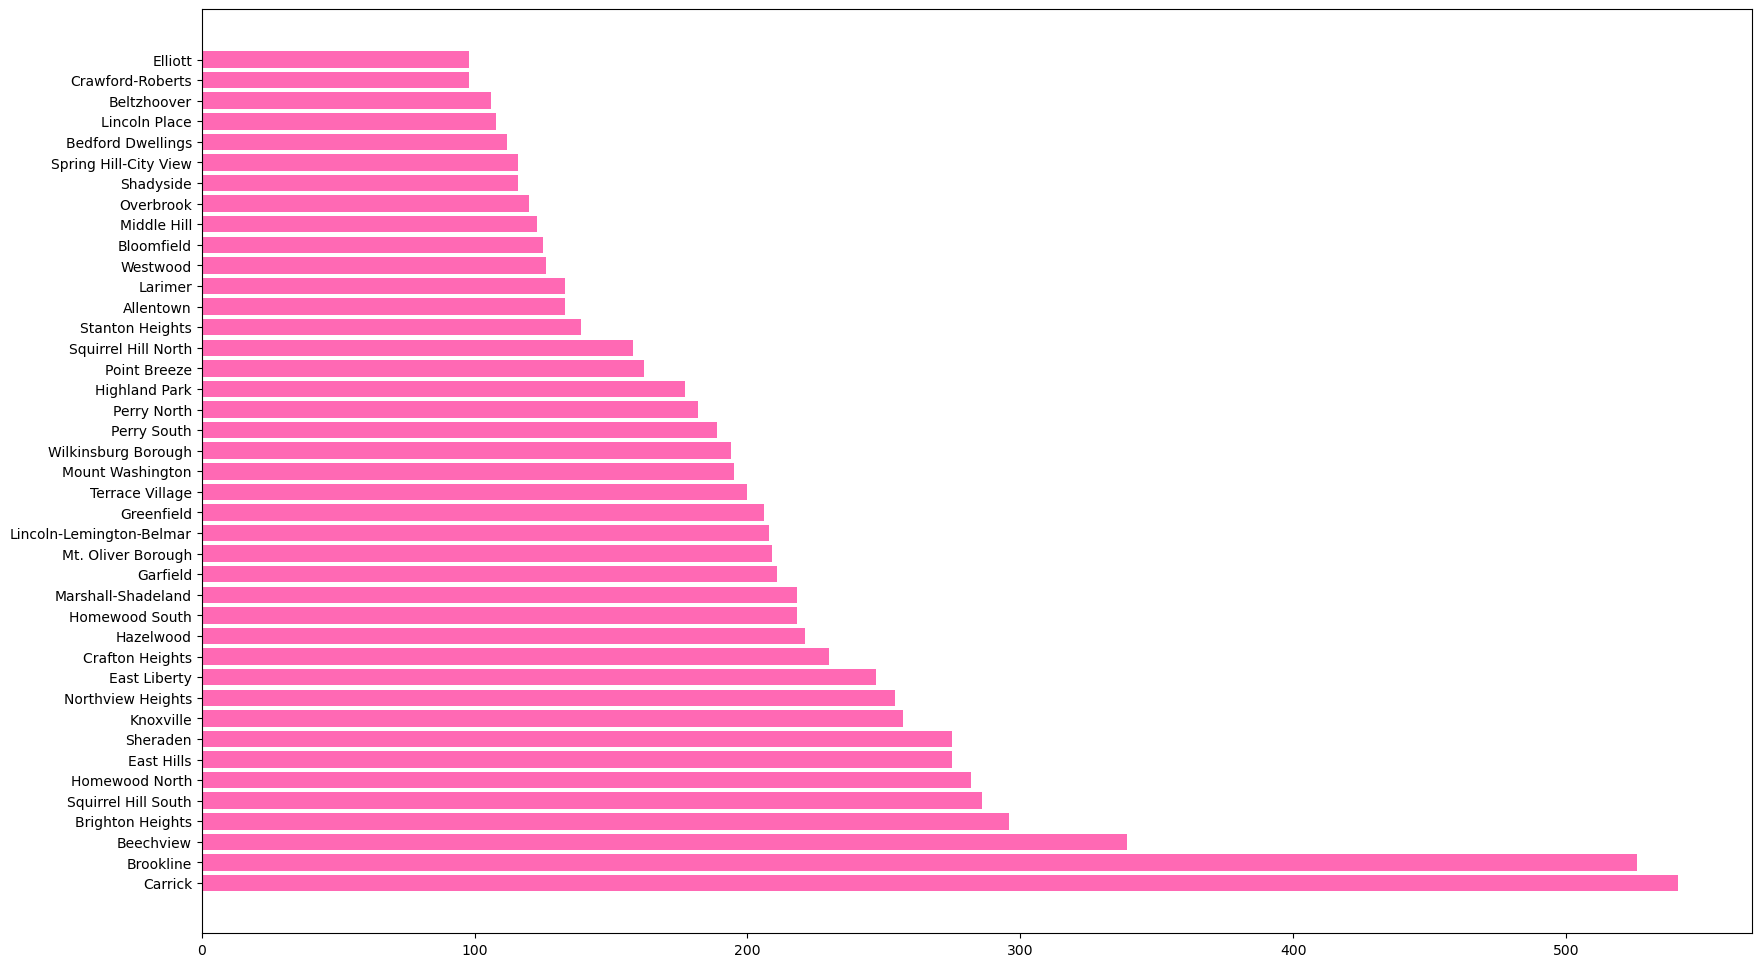

In [4]:
topGroup1 = enrollPerTown.nlargest(90, 'total_students_enrolled')
fig, ax = plt.subplots(figsize=(20, 12))
ax.barh(topGroup1['neighborhood'], topGroup1['total_students_enrolled'], color='#FF69B4')
plt.tight_layout
plt.show()

The chart I created above goes through and sorts through all of the data by enrollment by town, that is close to what we need but not exactly, as this chart fails to account for the differences in population between the different towns.

In [5]:
popData = popPerZip[['name', 'population']].copy()
popData.columns = ['zip_code', 'population']
popData['zip_code'] = popData['zip_code'].astype(str)

In [6]:
merged = pureEnroll.merge(popData, on='zip_code', how='left')
merged['studentsCap'] = (merged['total_students_enrolled'] / merged['population'] * 1000)

These lines of code are working to sort through the data and output it in a form that can be used to create a graph, alowing us to compare ad contrast the data

In [10]:
merged = merged.sort_values('total_students_enrolled', ascending=False)
merged[['neighborhood', 'total_students_enrolled', 'zip_code', 'population', 'studentsCap']]

,neighborhood,total_students_enrolled,zip_code,population,studentsCap
14,Carrick,1276.0,NaN,NaN,NaN
12,Brookline,1169.0,15226,13999.0,83.505965
6,Beechview,794.0,NaN,NaN,NaN
62,Sheraden,694.0,NaN,NaN,NaN
69,Squirrel Hill South,679.0,NaN,NaN,NaN
...,...,...,...,...,...
3,Arlington Heights,21.0,NaN,NaN,NaN
77,West End,17.0,NaN,NaN,NaN
17,Chartiers City,15.0,NaN,NaN,NaN
60,Saint Clair,13.0,NaN,NaN,NaN


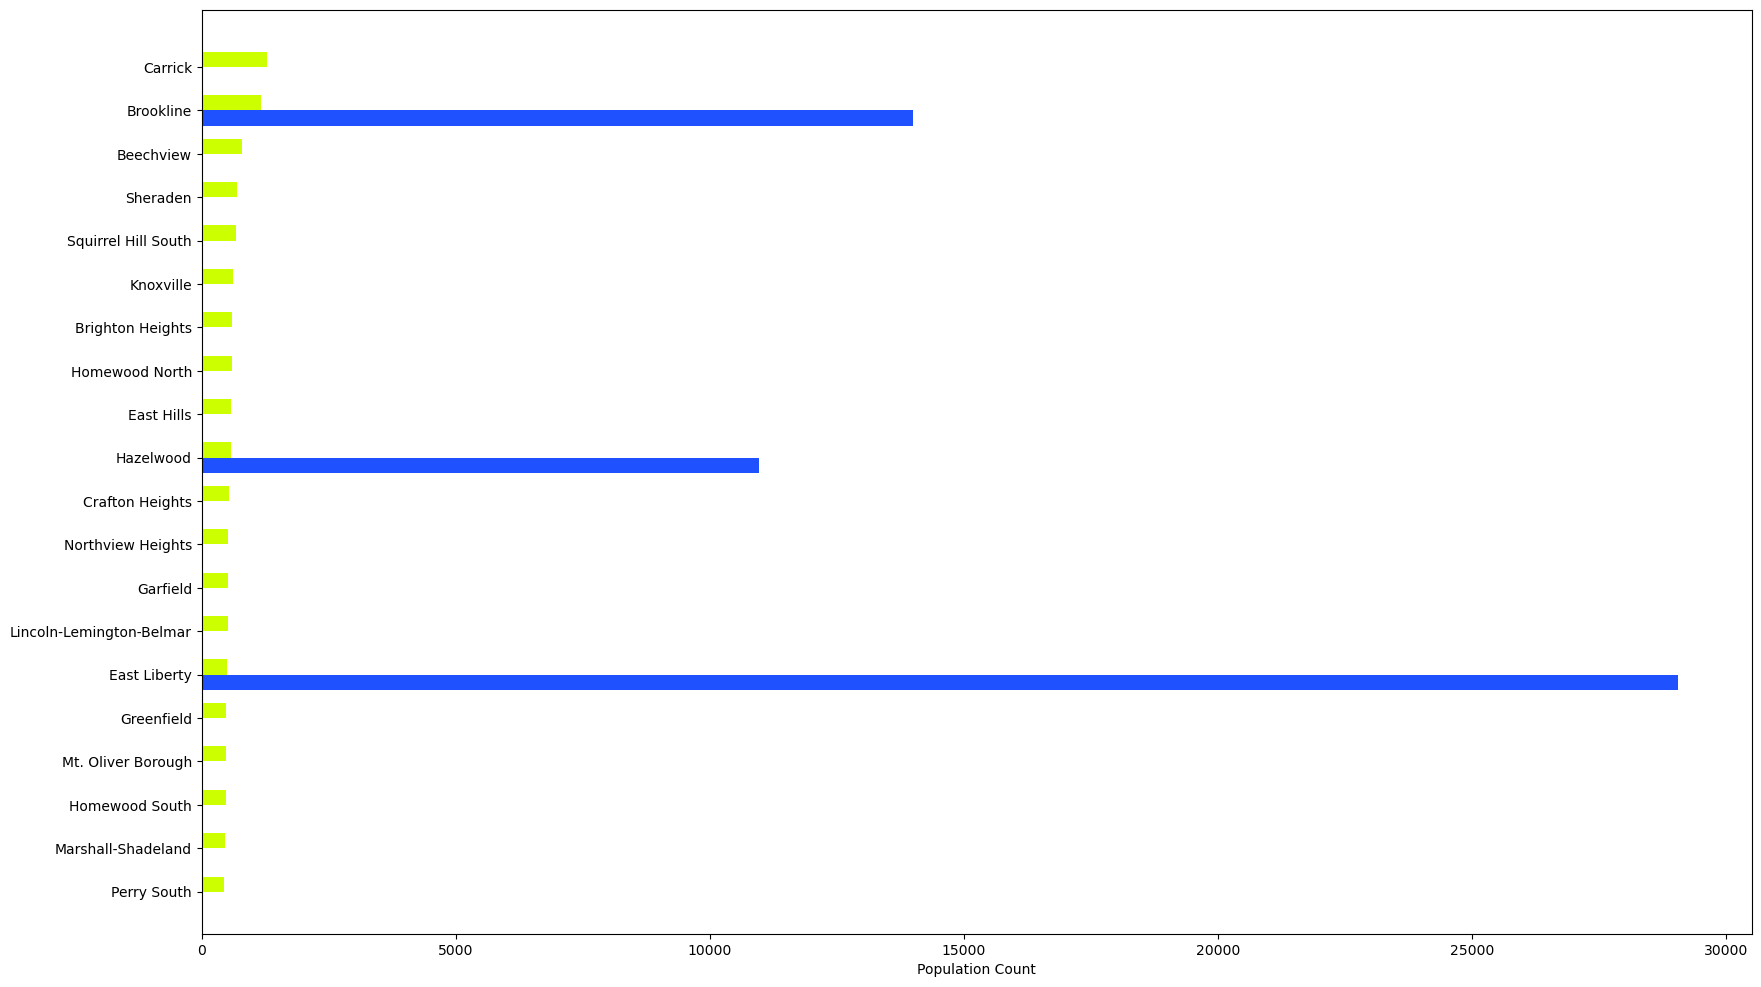

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

In [9]:
topGroup2 = merged.nlargest(20, 'total_students_enrolled').sort_values('total_students_enrolled')
fig, ax = plt.subplots(figsize=(20, 12))

HADD =range(len(topGroup2))
height = .35
ax.barh([y + height/2 for y in HADD], topGroup2['total_students_enrolled'], height, color='#CCFF00', label='Students currently enrolled')
ax.barh([y - height/2 for y in HADD], topGroup2['population'], height, color='#1F51FF', label = 'Population')
ax.set_xlabel('Population Count')

ax.legend
ax.set_yticks(HADD)
ax.set_yticklabels(topGroup2['neighborhood'])
plt.show()
plt.tight_layout

The chart above compares population vs enrollment. This gives you an idea of how much of the population is currently enrolled in schools town to town.